In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

In [3]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to DataFrame for easier handling
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

print("First 10 rows of the Iris dataset:\n", df.head(10))
print("\nTarget classes:", target_names)

First 10 rows of the Iris dataset:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  
5        0  
6  

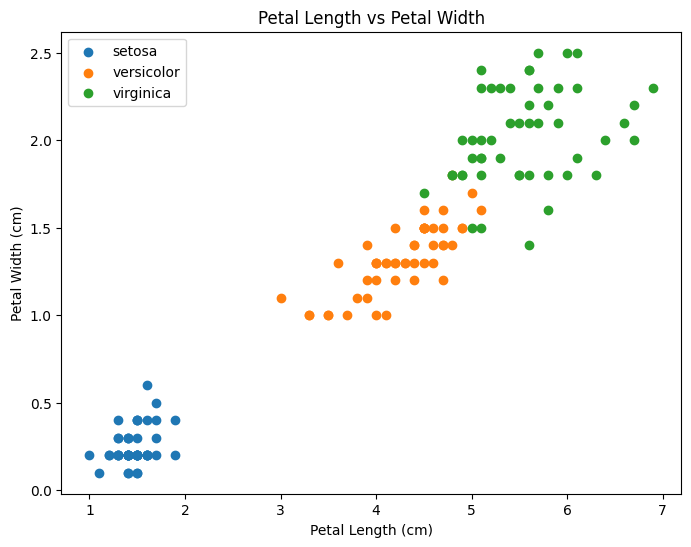

In [4]:
plt.figure(figsize=(8,6))
for species in np.unique(y):
    plt.scatter(df[df['species']==species]['petal length (cm)'],
                df[df['species']==species]['petal width (cm)'],
                label=target_names[species])
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Petal Length vs Petal Width')
plt.legend()
plt.show()

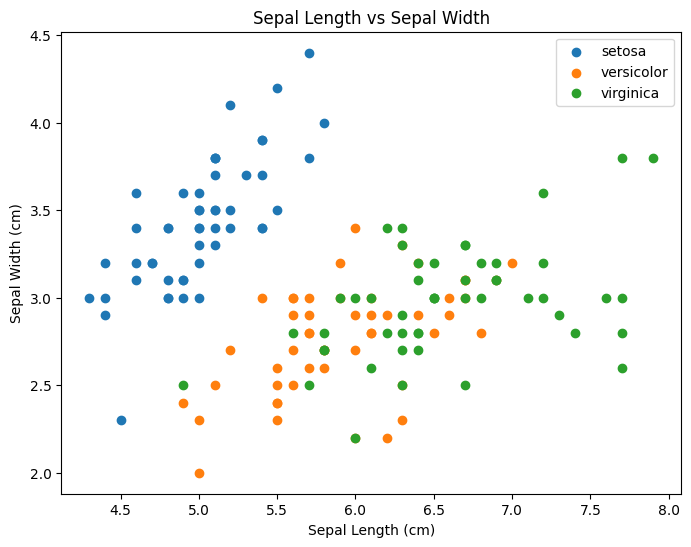

In [5]:
plt.figure(figsize=(8,6))
for species in np.unique(y):
    plt.scatter(df[df['species']==species]['sepal length (cm)'],
                df[df['species']==species]['sepal width (cm)'],
                label=target_names[species])
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend()
plt.show()


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize Decision Tree Classifier
dtree = DecisionTreeClassifier(criterion='entropy',random_state=42)
dtree.fit(X_train, y_train)

# Predict on test set
y_pred = dtree.predict(X_test)
print("\nPredicted classes for test set:", y_pred)


Predicted classes for test set: [1 0 2 1 1 0 1 2 1 1 1 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]


Accuracy of Decision Tree: 0.9777777777777777


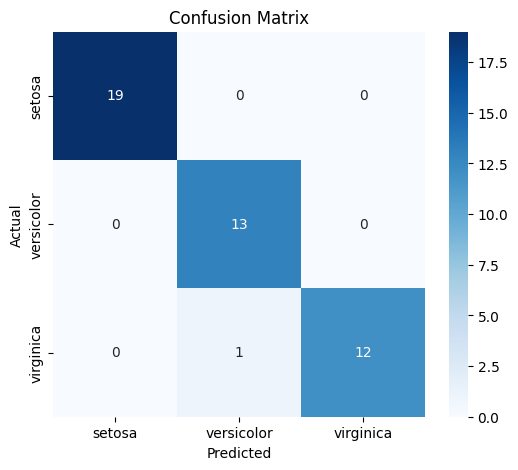

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Decision Tree:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [8]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Decision Tree:", accuracy)

Accuracy of Decision Tree: 0.9777777777777777


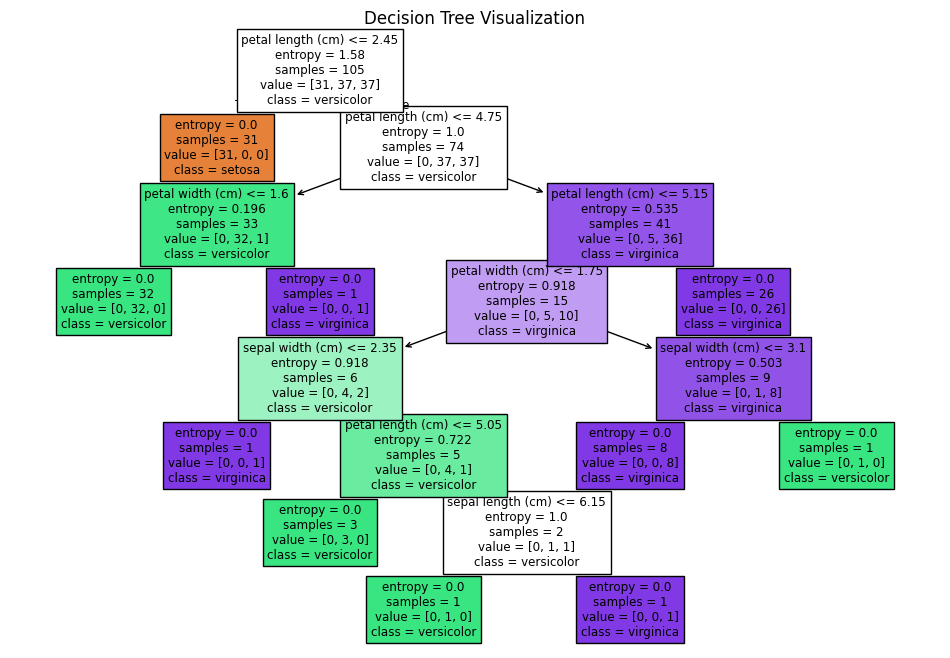

In [9]:
# 6. Decision Tree Visualization
# ------------------------------
plt.figure(figsize=(12,8))
plot_tree(dtree, feature_names=feature_names, class_names=target_names, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [10]:
# ------------------------------
# 7. Predict New Sample
# ------------------------------
new_sample = np.array([[5.4, 3.0, 4.5, 1.5]])  # Example input
predicted_class = dtree.predict(new_sample)
print(f"Predicted species for new sample: {target_names[predicted_class[0]]}")

Predicted species for new sample: versicolor
